Gradient Descent with Linear Regression Single Feature

model: f_wb = wx+b 

parameters: w,b 

cost: J_wb = (1/(2m)) * summ (f_wb_i - y_i)**2

gradient descent algorithm: w = w - alpha * (d/dw)J_wb

                            b = b - alpha * (d/db)J_wb

simultaneously reperat to convergence.

In [33]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# plt.style.available
plt.style.use("seaborn-v0_8")

In [34]:
def f_wb(x:np.ndarray,w:float,b=0):
    f_wb_i = w*x + b 
    return f_wb_i 

In [35]:
def J_wb(x:np.ndarray,y:np.ndarray,w:float,b=0):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb_i = f_wb(x[i],w,b)
        cost += (f_wb_i - y[i])**2
    total_cost = (1/(2*m)) * cost 
    return total_cost

In [36]:
def gradient(x:np.ndarray, y:np.ndarray, w:float, b=0):
    dj_dw = 0
    dj_db = 0
    m = x.shape[0]
    for i in range(m):
        f_wb_i = f_wb(x[i],w,b)
        dj_dw += (f_wb_i - y[i]) * x[i]
        dj_db += f_wb_i - y[i]
    dj_dw = (1/m)*dj_dw
    dj_db = (1/m)*dj_db 
    return dj_dw, dj_db 

In [37]:
def gradient_descent(x:np.ndarray,y:np.ndarray,w_in:float,b_in:float,iteration:int,alpha:float,cost_func,derivative_func):
    j_hist = []
    p_hist = []
    w = w_in 
    b = b_in 
    progress = []
    for i in range(iteration):
        dj_dw,dj_db = derivative_func(x,y,w,b)

        dj_dw = np.clip(dj_dw, -1e6, 1e6)
        dj_db = np.clip(dj_db, -1e6, 1e6)

        w = w - (alpha*dj_dw)
        b = b - (alpha*dj_db)

        j_hist.append(cost_func(x,y,w,b))  
        p_hist.append([w,b])

        if i % math.ceil(iteration/10) == 0:
            progress.append({
                "Iteration": i,
                "dj_dw": dj_dw,
                "dj_db": dj_db,
                "cost": j_hist[-1],
                "w" : w,
                "b" : b
            })
    return w,b,j_hist,p_hist,progress

In [38]:
# implementation
x_train = np.array([500, 800, 1000, 1200, 1500, 1800, 2000, 2500, 3000])/1000
y_train = np.array([75000, 120000, 150000, 180000, 225000, 270000, 300000, 375000, 450000])/1000
w_in = 0
b_in = 0
iter = 10000
alpha = 1e-2

w_final,b_final,J_hist,P_hist,progress = gradient_descent(x_train,y_train,w_in,b_in,iter,alpha,J_wb,gradient)

In [39]:
df = pd.DataFrame(progress)
print(df)

   Iteration       dj_dw       dj_db          cost           w          b
0          0 -467.833333 -238.333333  3.238548e+04    4.678333   2.383333
1       1000   -1.117361    2.088011  1.867133e+01  142.548913  13.923834
2       2000   -0.249698    0.466611  9.324372e-01  148.334894   3.111580
3       3000   -0.055800    0.104274  4.656545e-02  149.627896   0.695349
4       4000   -0.012470    0.023302  2.325456e-03  149.916845   0.155391
5       5000   -0.002787    0.005207  1.161321e-04  149.981417   0.034725
6       6000   -0.000623    0.001164  5.799581e-06  149.995847   0.007760
7       7000   -0.000139    0.000260  2.896282e-07  149.999072   0.001734
8       8000   -0.000031    0.000058  1.446389e-08  149.999793   0.000388
9       9000   -0.000007    0.000013  7.223195e-10  149.999954   0.000087


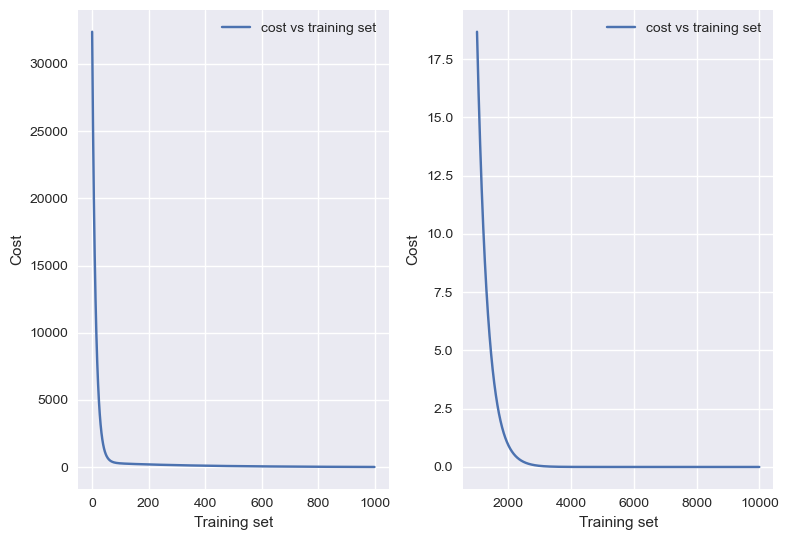

In [40]:
fig,(axe1,axe2) = plt.subplots(1,2,figure=(20,15))
axe1.plot(J_hist[:1000],label="cost vs training set")
axe1.legend()
axe2.plot(1000+np.arange(len(J_hist[1000:])),J_hist[1000:],label="cost vs training set")
axe2.legend()
axe1.set_xlabel("Training set")
axe2.set_xlabel("Training set")
axe1.set_ylabel("Cost")
axe2.set_ylabel("Cost")
plt.tight_layout()
plt.show()

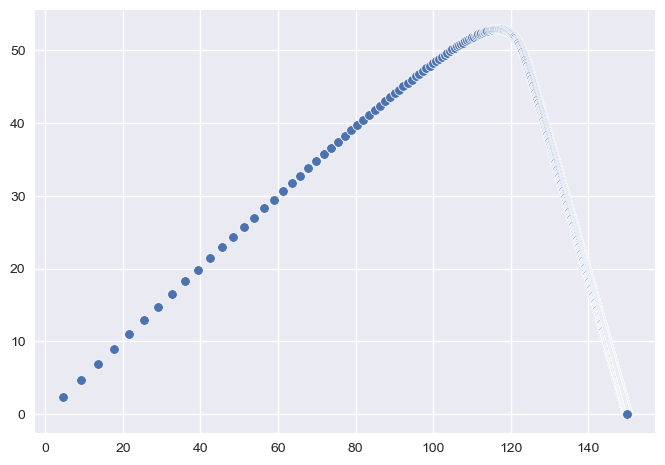

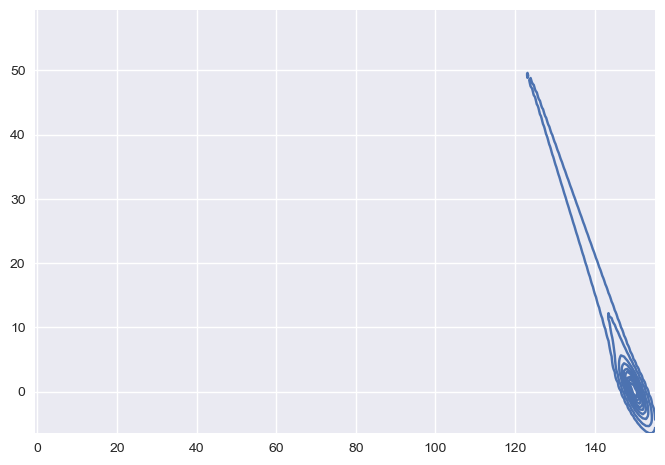

<Axes: >

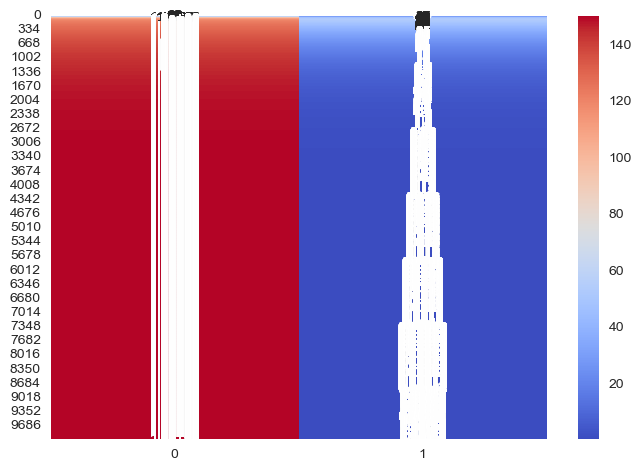

In [41]:
P_hist = np.array(P_hist)
w_hist = P_hist[:,0]
b_hist = P_hist[:,1]
sns.scatterplot(x=w_hist,y=b_hist)
plt.show()
sns.kdeplot(x=w_hist,y=b_hist)
plt.show()
sns.heatmap(P_hist,annot=True,cmap="coolwarm")

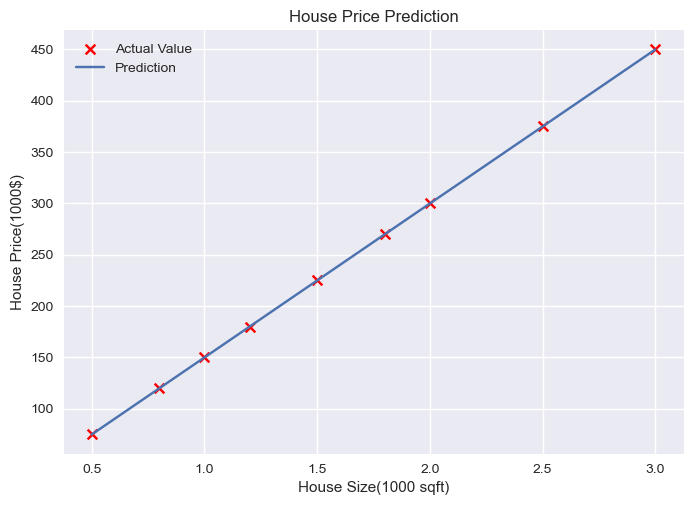

In [42]:
plt.scatter(x_train,y_train,marker="x",c="r",label="Actual Value")
plt.plot(x_train, w_final*x_train + b_final, label="Prediction")
plt.title("House Price Prediction")
plt.xlabel("House Size(1000 sqft)")
plt.ylabel("House Price(1000$)")
plt.legend()
plt.show()


In [46]:
user_in = float(input("Enter House Size (sqft): "))
prediction = w_final * user_in + b_final 

print(f"House Size: {user_in}sqft")
print(f"House Price: ${prediction:,.0f}")

House Size: 700.0sqft
House Price: $105,000
